In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_basic.fits'))
pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_pz_new.fits', columns=['Z_PHOT_MEDIAN']))
lrgmask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.1.1/resolve/dr9_lrg_1.1.1_lrgmask_v1.1.fits.gz'))
cat = hstack([cat, pz, lrgmask], join_type='exact')
print(len(cat))

12338990


In [4]:
# maskbits = [1, 8, 9, 11, 12, 13]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print(np.sum(~mask_clean)/len(mask_clean))
# cat = cat[mask_clean]
# print(len(cat))

mask_clean = cat['lrg_mask']==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

0.12328391545823443
10817791


In [5]:
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
#     rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
#     zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
#     w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
#     w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
#     zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

#     gmag[~np.isfinite(gmag)] = 100.
#     rmag[~np.isfinite(rmag)] = 100.
#     zmag[~np.isfinite(zmag)] = 100.
#     w1mag[~np.isfinite(w1mag)] = 100.
#     w2mag[~np.isfinite(w2mag)] = 100.
#     zfibermag[~np.isfinite(zfibermag)] = 100.

# cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag'])

In [6]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
mask_south &= cat['DEC']>-30
print(np.sum(mask_north), np.sum(mask_south))

2741653 6393093


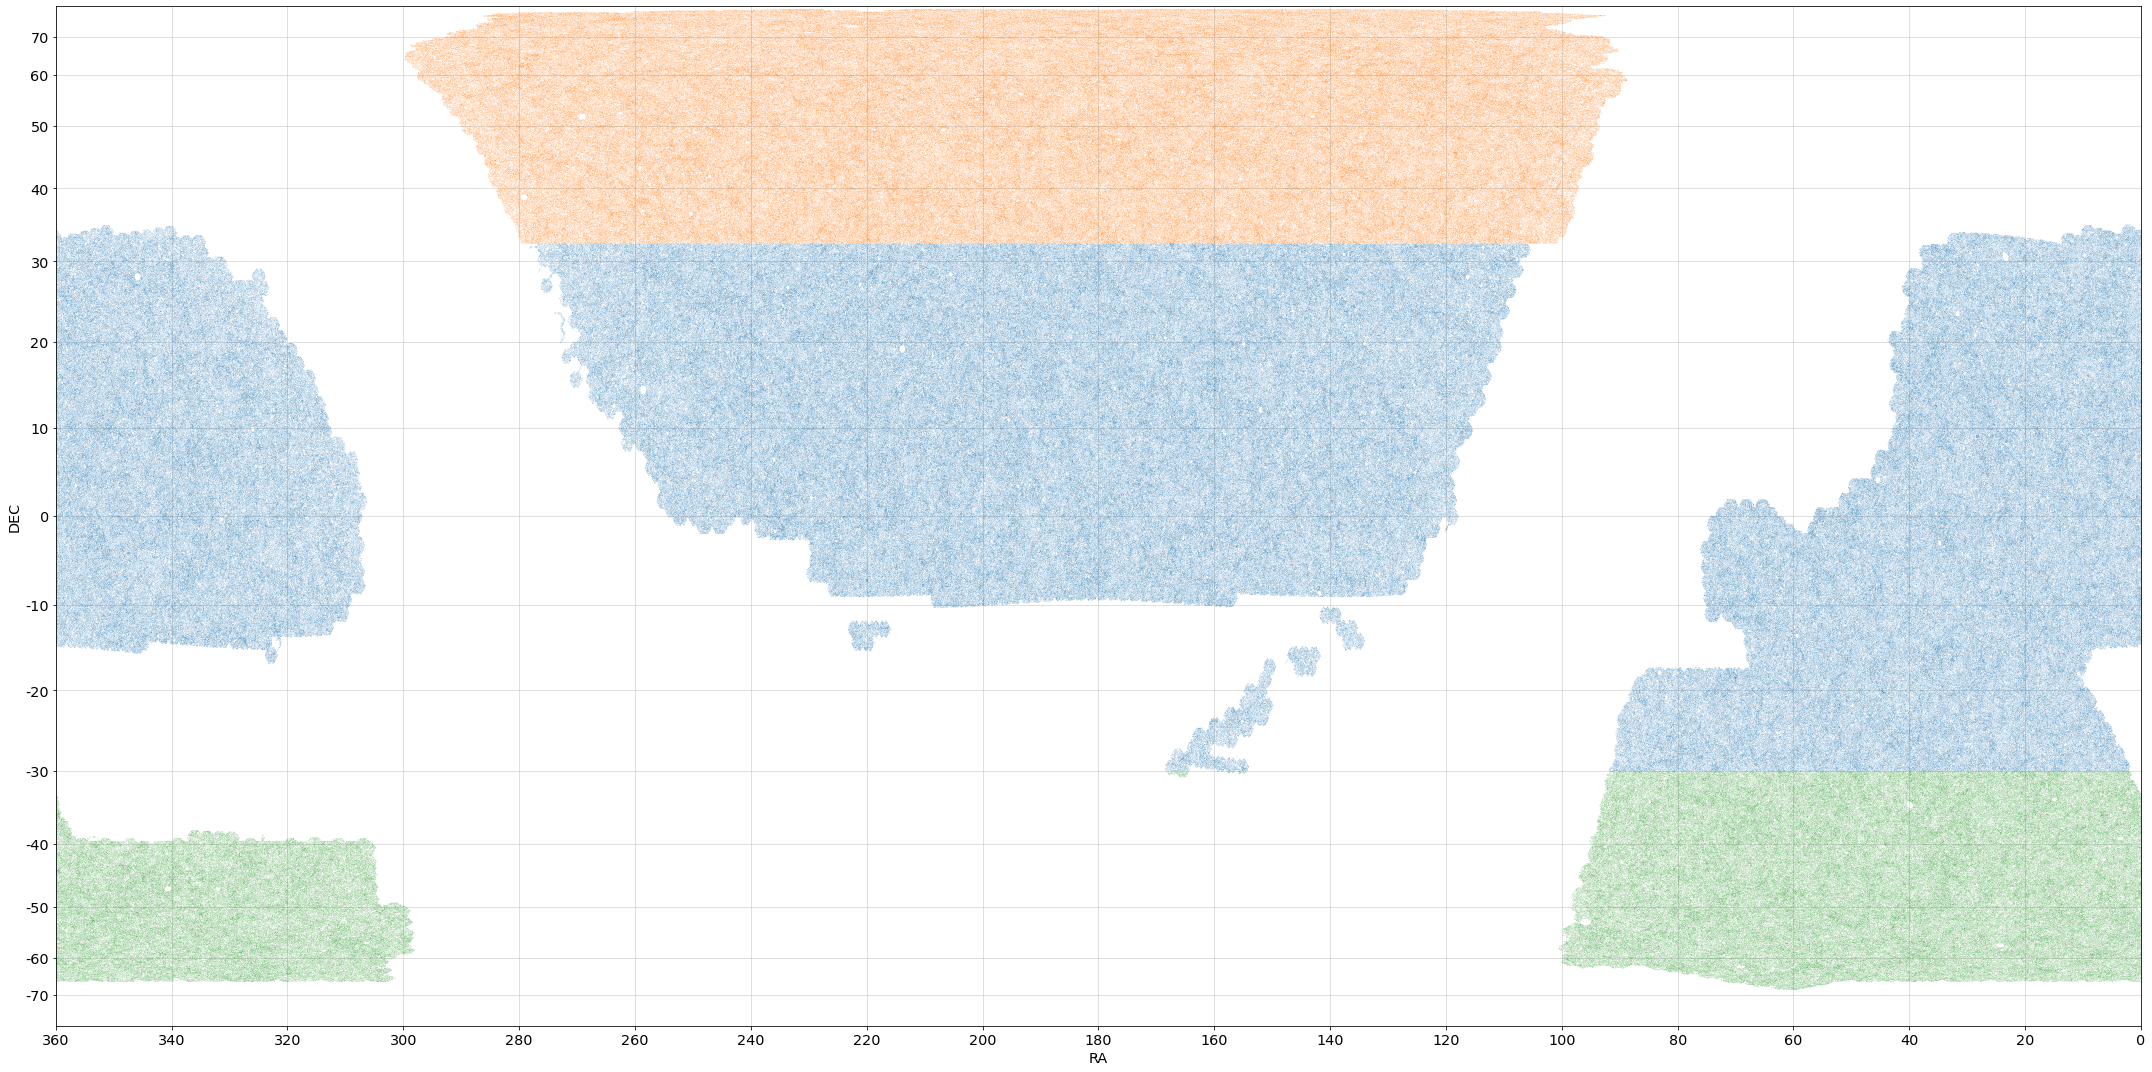

In [7]:
fig, ax = plt.subplots(figsize=(30, 15))
ax.plot(cat['RA'][mask_south], np.sin(np.radians(cat['DEC'][mask_south])), '.', ms=0.02, alpha=1)
ax.plot(cat['RA'][mask_north], np.sin(np.radians(cat['DEC'][mask_north])), '.', ms=0.02, alpha=1)
ax.plot(cat['RA'][~(mask_south | mask_north)], np.sin(np.radians(cat['DEC'][~(mask_south | mask_north)])), '.', ms=0.02, alpha=1)
ax.axis([360, 0, -1., 1.])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 80, 10))))
ax.set_yticklabels(np.arange(-70, 80, 10))
ax.set_xticks(np.arange(0, 361, 20))
ax.grid(alpha=0.5)
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
plt.tight_layout()
plt.show()

----------
## South

In [8]:
mask0 = mask_south.copy()

In [9]:
mask = mask0 & (cat['Z_PHOT_MEDIAN']>0.4) & (cat['Z_PHOT_MEDIAN']<1.1)
print(np.percentile(cat['Z_PHOT_MEDIAN'][mask], [0.001, 20, 40, 60, 80, 99.9]))

[0.40001262 0.58496994 0.70826426 0.82256351 0.89946334 1.09522864]


In [10]:
pz_cuts = [0.400, 0.540, 0.713, 0.860, 1.020]
print(pz_cuts)

for index in range(len(pz_cuts)-1):
    pz_min, pz_max = pz_cuts[index], pz_cuts[index+1]
    mask = mask0 & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/np.sum(mask0), np.sum(mask)/np.sum(mask0)*610))
    
percentiles = []
for index in range(len(pz_cuts)):
    pz_max = pz_cuts[index]
    mask = mask0 & (cat['Z_PHOT_MEDIAN']<pz_max)
    percentiles.append(np.sum(mask)/np.sum(mask0)*100)
print(percentiles)

[0.4, 0.54, 0.713, 0.86, 1.02]
13.44% (82.0 per sqdeg)
24.46% (149.2 per sqdeg)
27.12% (165.4 per sqdeg)
24.86% (151.7 per sqdeg)
[6.0529386949321715, 19.49421039237189, 43.957502260642855, 71.07514312712172, 95.93592647565114]


In [11]:
mask0 = mask_south.copy()
percentiles = []
for index in range(len(pz_cuts)):
    pz_max = pz_cuts[index]
    mask = (cat['Z_PHOT_MEDIAN'][mask0]<pz_max)
    mask1 = (cat['Z_PHOT_MEDIAN'][mask0]>0.4)
    percentiles.append(np.sum(mask & mask1)/np.sum(mask1)*100)
print(percentiles)

[0.0, 14.307282751285646, 40.34672616594765, 69.21153629387877, 95.67408126673396]


----------
## North

In [12]:
mask0 = mask_north.copy()

In [13]:
mask = mask0 & (cat['Z_PHOT_MEDIAN']>0.4) & (cat['Z_PHOT_MEDIAN']<1.1)
print(np.percentile(cat['Z_PHOT_MEDIAN'][mask], [0.001, 20, 40, 60, 80, 99.9]))

[0.400013   0.58769865 0.71144753 0.81668017 0.88950562 1.0957067 ]


In [14]:
pz_cuts = [0.400, 0.545, 0.719, 0.851, 1.024]
print(pz_cuts)

for index in range(len(pz_cuts)-1):
    pz_min, pz_max = pz_cuts[index], pz_cuts[index+1]
    mask = mask0 & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    print('{:.2f}% ({:.1f} per sqdeg)'.format(100*np.sum(mask)/np.sum(mask0), np.sum(mask)/np.sum(mask0)*610))
    
percentiles = []
for index in range(len(pz_cuts)):
    pz_max = pz_cuts[index]
    mask = mask0 & (cat['Z_PHOT_MEDIAN']<pz_max)
    percentiles.append(np.sum(mask)/np.sum(mask0)*100)
print(percentiles)

[0.4, 0.545, 0.719, 0.851, 1.024]
13.82% (84.3 per sqdeg)
24.70% (150.7 per sqdeg)
27.10% (165.3 per sqdeg)
24.91% (152.0 per sqdeg)
[5.402434224900087, 19.21898941988647, 43.91708213986234, 71.02149688527322, 95.93135965784145]


In [15]:
mask0 = mask_south.copy()
percentiles = []
for index in range(len(pz_cuts)):
    pz_max = pz_cuts[index]
    mask = (cat['Z_PHOT_MEDIAN'][mask0]<pz_max)
    mask1 = (cat['Z_PHOT_MEDIAN'][mask0]>0.4)
    percentiles.append(np.sum(mask & mask1)/np.sum(mask1)*100)
print(percentiles)

[0.0, 14.908535839176121, 41.37011513084231, 66.73960889578852, 95.92387635085062]
